In [1]:
# connection between Python and MySQL database
import sys
!{sys.executable} -m pip install mysql-connector-python

In [2]:
import mysql.connector
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

conn = mysql.connector.connect(
    host="localhost",
    user="root",
    password="Chinu@#1993@#",
    database="aegislife_insurance"
)

print("Connected successfully")

Connected successfully


In [13]:
# Table names 
cursor = conn.cursor()
cursor.execute("SHOW TABLES")

for table in cursor:
    print(table)

('agent_info',)
('claim_history',)
('customer_feedback_surveys',)
('customer_master',)
('policy_details',)


In [14]:
# Loading tables into DataFrames

agent_df = pd.read_sql("SELECT * FROM agent_info", conn)
claim_df = pd.read_sql("SELECT * FROM claim_history", conn)
feedback_df = pd.read_sql("SELECT * FROM customer_feedback_surveys", conn)
customer_df = pd.read_sql("SELECT * FROM customer_master", conn)
policy_df = pd.read_sql("SELECT * FROM policy_details", conn)

print("Agent Info:", agent_df.shape)
print("Claim History:", claim_df.shape)
print("Feedback:", feedback_df.shape)
print("Customer Master:", customer_df.shape)
print("Policy Details:", policy_df.shape)

Agent Info: (300, 7)
Claim History: (1406, 8)
Feedback: (999, 7)
Customer Master: (1648, 11)
Policy Details: (2828, 9)


C:\Users\Tanush\AppData\Local\Temp\ipykernel_14372\1878407432.py:3: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  agent_df = pd.read_sql("SELECT * FROM agent_info", conn)
C:\Users\Tanush\AppData\Local\Temp\ipykernel_14372\1878407432.py:4: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  claim_df = pd.read_sql("SELECT * FROM claim_history", conn)
C:\Users\Tanush\AppData\Local\Temp\ipykernel_14372\1878407432.py:5: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  feedback_df = pd.read_sql("SELECT * FROM customer_feedback_surveys", c

In [20]:
# Viweing files


agent_df.head()

,Agent_ID,region,join_date,total_policies_sold,lapsed_policies,avg_premium_sold,fraud_association
0,AGT5000,North,2016-02-15,196,42,37018.35,8
1,AGT5001,North,2016-09-05,189,28,48370.36,5
2,AGT5002,South,2016-06-26,66,0,10489.65,3
3,AGT5003,North-East,2016-04-23,250,3,12415.84,6
4,AGT5004,South,2022-11-16,263,69,24057.14,4


In [44]:
# Normalize column names

agent_df.columns = agent_df.columns.str.strip().str.lower()
claim_df.columns = claim_df.columns.str.strip().str.lower()
feedback_df.columns = feedback_df.columns.str.strip().str.lower()
customer_df.columns = customer_df.columns.str.strip().str.lower()
policy_df.columns = policy_df.columns.str.strip().str.lower()


In [45]:
# checking missing data, duplicates, datatypes in all dataframes
tables = {
    "agent_info": agent_df,
    "claim_history": claim_df,
    "customer_feedback_surveys": feedback_df,
    "customer_master": customer_df,
    "policy_details": policy_df
}

for name, df in tables.items():
    print("=" * 60)
    print(f"TABLE: {name}")
    print("=" * 60)
    
    print("Shape:", df.shape)
    print("\nData Types:")
    print(df.dtypes)
    
    print("\nMissing Values:")
    print(df.isnull().sum())
    
    print("\nDuplicates:", df.duplicated().sum())
    
    print("\nSummary Stats:")
    print(df.describe(include='all'))
    
    print("\n")

TABLE: agent_info
Shape: (300, 7)

Data Types:
agent_id                       object
region                         object
join_date              datetime64[ns]
total_policies_sold             int64
lapsed_policies                 int64
avg_premium_sold              float64
fraud_association               int64
dtype: object

Missing Values:
agent_id               0
region                 0
join_date              0
total_policies_sold    0
lapsed_policies        0
avg_premium_sold       0
fraud_association      0
dtype: int64

Duplicates: 0

Summary Stats:
       agent_id region            join_date  total_policies_sold  \
count       300    300                  300           300.000000   
unique      300      6                  NaN                  NaN   
top     AGT5000  North                  NaN                  NaN   
freq          1     56                  NaN                  NaN   
mean        NaN    NaN  2018-12-07 03:40:48           175.973333   
min         NaN    NaN  2015-

In [7]:
# Data Validation Summary

## Data Quality Status
## No duplicates found across all 5 tables
## No missing values in 4 out of 5 tables
## Customer feedback table has 369 missing Customer IDs (~36.9%)
## Date columns require datetime conversion

## Key Business Metrics
## Total Claims: 1406
## Avg Claim Amount: 252,932
## Avg Processing Time: 31 days
## Total Policies: 2828
## Avg Annual Premium: 26,685

In [46]:
# Date conversion

claim_df['claim_date'] = pd.to_datetime(claim_df['claim_date'])
policy_df['policy_start_date'] = pd.to_datetime(policy_df['policy_start_date'])
policy_df['policy_end_date'] = pd.to_datetime(policy_df['policy_end_date'])
customer_df['date_joined'] = pd.to_datetime(customer_df['date_joined'])
agent_df['join_date'] = pd.to_datetime(agent_df['join_date'])

In [47]:
# Fraud Ratio

fraud_ratio = claim_df['fraud_flag'].value_counts(normalize=True) * 100
print(fraud_ratio)

fraud_flag
No     50.995733
Yes    49.004267
Name: proportion, dtype: float64


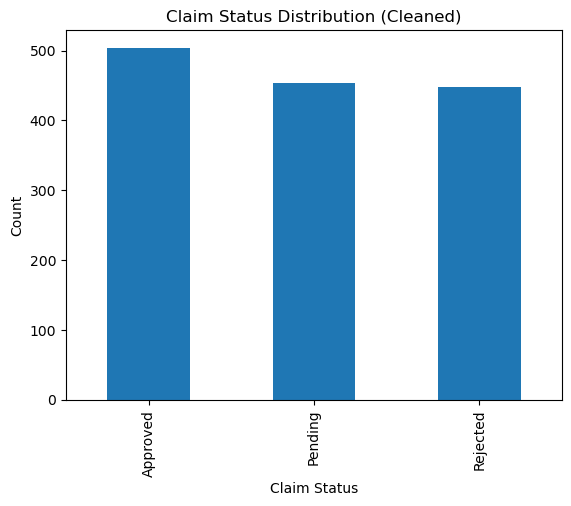

In [48]:
# Claim status distribution chart
claim_df['claim_status'].value_counts().plot(kind='bar')
plt.title("Claim Status Distribution (Cleaned)")
plt.xlabel("Claim Status")
plt.ylabel("Count")
plt.show()

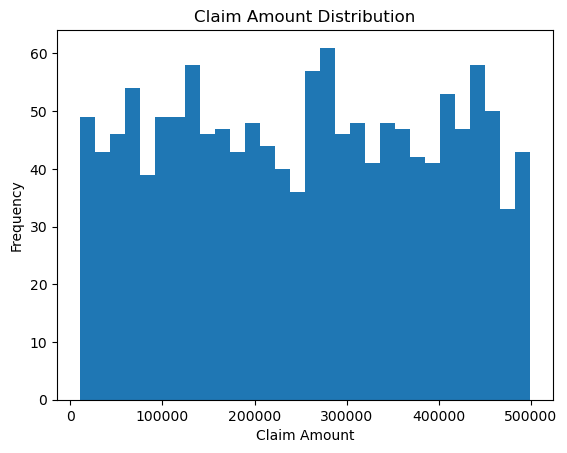

In [49]:
# Claim amount distribution
claim_df['claim_amount'].plot(kind='hist', bins=30)
plt.title("Claim Amount Distribution")
plt.xlabel("Claim Amount")
plt.show()

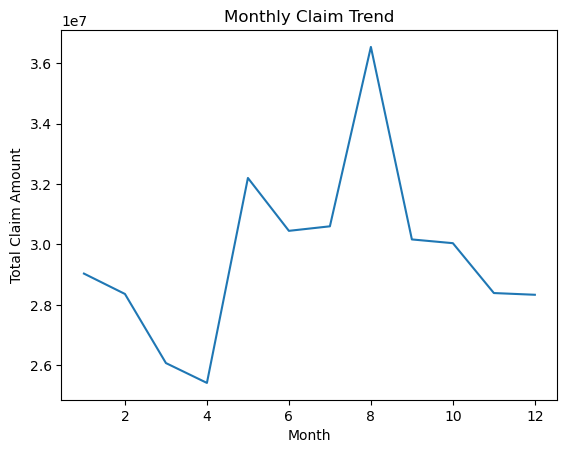

In [50]:
# Monthly claims trend

monthly_claims = claim_df.groupby(claim_df['claim_date'].dt.month)['claim_amount'].sum()

monthly_claims.plot(kind='line')
plt.title("Monthly Claim Trend")
plt.xlabel("Month")
plt.ylabel("Total Claim Amount")
plt.show()

fraud_flag   No  Yes
claim_type          
Accident    147  140
Death       128  157
Hospital    136  131
Other       146  131
Theft       160  130


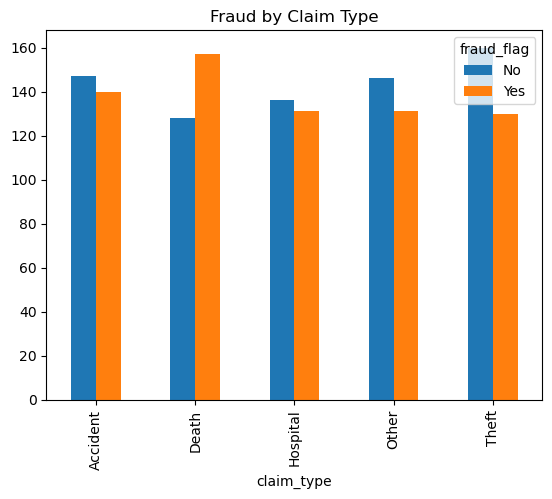

In [52]:
# Fraud by claim type

fraud_by_type = pd.crosstab(claim_df['claim_type'], claim_df['fraud_flag'])
print(fraud_by_type)

fraud_by_type.plot(kind='bar')
plt.title("Fraud by Claim Type")
plt.show()

In [53]:
# Processing time by fraud
claim_df.groupby('fraud_flag')['days_to_process'].mean()

fraud_flag
No     31.124128
Yes    31.222061
Name: days_to_process, dtype: float64

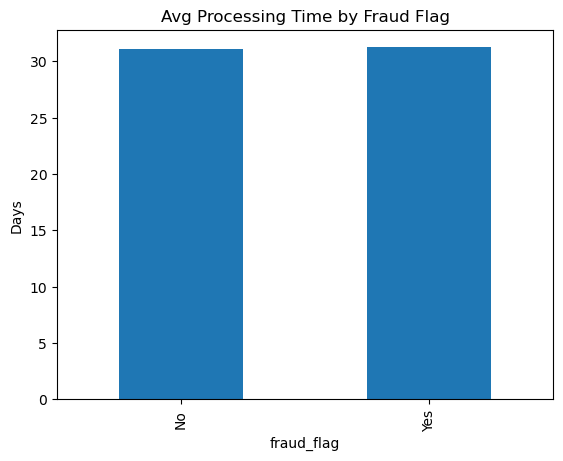

In [54]:
# Processing time by fraud - Bar Chart 
claim_df.groupby('fraud_flag')['days_to_process'].mean().plot(kind='bar')
plt.title("Avg Processing Time by Fraud Flag")
plt.ylabel("Days")
plt.show()

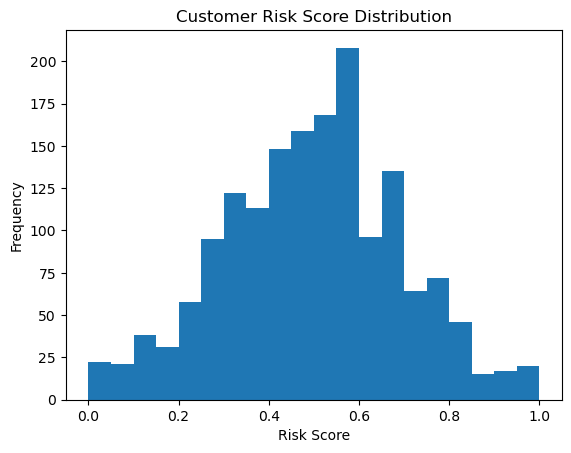

In [55]:
# Customer risk analysis

customer_df['risk_score'].plot(kind='hist', bins=20)
plt.title("Customer Risk Score Distribution")
plt.xlabel("Risk Score")
plt.show()

In [56]:
#  Premium analysis
policy_df.groupby('product_type')['annual_premium'].mean()

product_type
Health      26422.001949
Property    25978.663175
Term        27137.827927
Vehicle     27191.550135
Whole       26702.184685
Name: annual_premium, dtype: float64

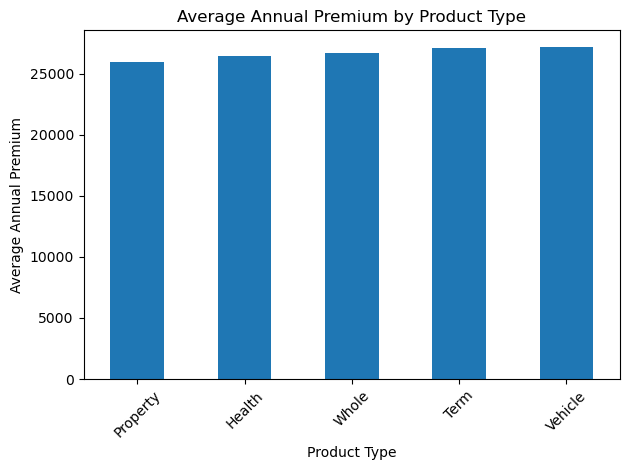

In [57]:
premium_by_product = policy_df.groupby('product_type')['annual_premium'].mean().sort_values()

premium_by_product.plot(kind='bar')
plt.title("Average Annual Premium by Product Type")
plt.xlabel("Product Type")
plt.ylabel("Average Annual Premium")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [63]:
# Defining business hypotheses

# Hypothesis 1 — Smoker vs Non-smoker claim amount
# H0: Average claim amount of smokers = non-smokers
# H1: Average claim amount of smokers ≠ non-smokers

# Business logic:
# Smokers may have higher health risk, leading to higher claim severity.

# Hypothesis 2 — Claim amount differs across regions
# H0: Mean claim amount is same across all regions
# H1: At least one region has significantly different claim amount

# Business logic:
# Different regions may have varying healthcare costs, lifestyle patterns,
# and access to medical facilities, which can impact claim severity.

# Hypothesis 3 — Claim status depends on claim type
# H0: Claim_Status and Claim_Type are independent
# H1: They are associated

# Business logic:
# Certain claim types (e.g., accidental, medical, theft) may have different
# verification complexity and approval rules, affecting claim status.


# Hypothesis 4 — Risk score correlates with claim amount
# H0: No correlation between risk score and claim amount
# H1: Significant correlation exists

# Business logic:
# Higher risk score customers are expected to generate higher claim amounts,
# as risk scoring is designed to capture potential claim severity.

In [59]:
# Build analytical merged dataset

analysis_df = (
    claim_df
    .merge(policy_df[["policy_id", "customer_id", "product_type"]],
           on="policy_id")
    .merge(customer_df[["customer_id", "smoking_status", "region", "risk_score"]],
           on="customer_id")
)

analysis_df.head()

,claim_id,policy_id,claim_date,claim_amount,claim_status,claim_type,fraud_flag,days_to_process,customer_id,product_type,smoking_status,region,risk_score
0,CLM70003,POL51902,2022-10-10,379127.79,Pending,Theft,No,40,CUST11700,Term,No,East,0.29
1,CLM70004,POL50001,2021-12-06,431984.06,Approved,Hospital,No,56,CUST10833,Property,Yes,Central,0.56
2,CLM70005,POL53707,2024-07-17,206765.82,Rejected,Death,No,39,CUST11843,Property,No,North,0.51
3,CLM70006,POL53642,2024-06-12,225358.05,Approved,Accident,Yes,22,CUST11314,Vehicle,No,East,0.23
4,CLM70007,POL51744,2024-06-13,340208.27,Rejected,Theft,No,31,CUST10557,Whole,No,South,0.84


In [71]:
# T-test (Smoker vs Non-smoker)

from scipy.stats import ttest_ind

smoker_claims = analysis_df[
    analysis_df["smoking_status"] == "Yes"
]["claim_amount"]

nonsmoker_claims = analysis_df[
    analysis_df["smoking_status"] == "No"
]["claim_amount"]

t_stat, p_value = ttest_ind(smoker_claims, nonsmoker_claims)

print("T-statistic:", t_stat)
print("P-value:", p_value)

T-statistic: 1.886045209401794
P-value: 0.05949511716479754


In [72]:
# Hypothesis 1
# T-Test — Smoker vs Non-smoker claim amount
# H0: Average claim amount of smokers = non-smokers
# H1: Average claim amount of smokers ≠ non-smokers

# Result
# t-statistic: 1.886045209401794
# p-value: 0.05949511716479754

# Decision Rule:
# If p-value < 0.05 → Reject H0
# Interpretation: Statistically significant difference exists

# Business Insight:
# Smoking status is a potential risk factor affecting claim severity

In [67]:
# ANOVA (Region-wise claim amount)

from scipy.stats import f_oneway

groups = [
    group["claim_amount"].values
    for _, group in analysis_df.groupby("region")
]

f_stat, p_value = f_oneway(*groups)

print("F-statistic:", f_stat)
print("P-value:", p_value)

F-statistic: 0.7633687404838203
P-value: 0.5762394310657502


In [ ]:
# Hypothesis 3
# ANOVA Test: Claim amount across different regions
# H0: Mean claim amount is same across all regions
# H1: At least one region has a different mean claim amount
# Significance level: 0.05

# Result:
# F-statistic = 0.763
# p-value = 0.576

# Decision Rule:
# Since p-value > 0.05, we fail to reject H0

# Conclusion:
# There is no statistically significant difference in claim amounts across regions

# Business Insight:
# Region is not a strong driver of claim severity in this dataset
# Risk and claim behavior appear consistent across geographies

In [69]:
# Chi-square test

from scipy.stats import chi2_contingency

contingency_table = pd.crosstab(
    claim_df["claim_status"],
    claim_df["claim_type"]
)

chi2, p_value, dof, expected = chi2_contingency(contingency_table)

print("Chi-square:", chi2)
print("P-value:", p_value)

Chi-square: 6.282571320748683
P-value: 0.6156122603580061


In [73]:
# Hypothesis 3
#Chi-square Test: Relationship between Claim Status and Claim Type
# H0: Claim_Status and Claim_Type are independent
# H1: They are associated

# Business logic:
# Certain claim types (e.g., accidental, medical, theft) may have different
# verification complexity and approval rules, affecting claim status.
# Significance level: 0.05

# Result:
# Chi-square statistic = 6.283
# p-value = 0.616

# Decision:
# Since p-value > 0.05, we fail to reject H0

# Conclusion:
# Claim status and claim type are statistically independent

# Business Insight:
# Claim type does not significantly influence claim approval/rejection status
# Claim processing outcomes appear consistent across different claim categories

In [70]:
# Correlation test

from scipy.stats import pearsonr

corr, p_value = pearsonr(
    analysis_df["risk_score"],
    analysis_df["claim_amount"]
)

print("Correlation:", corr)
print("P-value:", p_value)

Correlation: -0.015668044103048524
P-value: 0.5571950246861304


In [ ]:
# Hypothesis 4
# Correlation Test: Relationship between Risk Score and Claim Amount
# H0: No correlation between risk score and claim amount
# H1: Significant correlation exists

# Result:
# Correlation coefficient = -0.016 (approx)
# p-value = 0.557

# Decision:
# Since p-value > 0.05, we fail to reject H0

# Conclusion:
# There is no statistically significant linear relationship between risk score and claim amount

# Business Insight:
# Risk score does not appear to be a strong predictor of claim amount in this dataset
# Claim severity is likely influenced by other factors (e.g., policy type, demographics, behavior)